# 01. Actor 도출
- MeCab 형태소 분석기 활용
- Doc2Vec 벡터화 → Ward 클러스터링 → TF-IDF 해석

In [1]:
# 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# 작업 경로 이동
import os
BASE_PATH = '/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/CX 프로젝트/가전 구독/가전 구독'
os.chdir(BASE_PATH)
!pwd

/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/CX 프로젝트/가전 구독/가전 구독


In [7]:
!ls

ko-stopwords.csv		  lg_subscription_v5.csv
lg_subscription_full_text_v2.csv  SentiWord_info.json


In [8]:
# 필요 라이브러리 설치
!pip install -q python-mecab-ko
!pip install -q new_value_analysis
!pip install -q konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 14.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 33.4 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.6 MB/s eta 0:00:00:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 51.3 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 32.1 MB/s eta 0:00:00


### 1. 데이터 로딩

In [9]:
import pandas as pd

df = pd.read_csv('./LG_subscription_final.csv')
print('원본 데이터 shape:', df.shape)
df.head()

원본 데이터 shape: (314, 5)


,카테고리,플랫폼,키워드,url,full_text
0,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/ko_jaeeun/224215586086,전자 베스트샵 왕십리 가전구독 알아본 후기 날씨가 점점 풀리고 봄이 다가오니 결혼 ...
1,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/jinipick__/224198462710,핵심 요약 결론 스타일러 5년 구독 시 일시불 구매보다 약 75만 원의 추가 비용이...
2,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/hohobaby/224032029753,가전 구독 홍보 홈플러스 잠실점에서 만나요 이제 친근한 단어로 느껴지는 구독 앞서가...
3,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/allaboutcanada/22392598...,이 컨텐츠는 전자로부터 제품을 지원받아 작성했습니다. 안녕하세요! 햇지입니다 장마철...
4,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/jej3480/223866954502,홈플러스금천 가전 구독 서비스 궁금하잖아 다녀온 후기 홈플러스 가전 구독은 어떻게 ...


### 2. 데이터 전처리

In [10]:
import re

# 결측치 및 수집 실패 데이터 제거
df = df.dropna(subset=['full_text'])
df = df[~df['full_text'].str.contains('본문 추출 실패|본문 내용 없음|회원 공개글', na=False)]
df = df.reset_index(drop=True)

# 특수문자 제거
pattern = r'[^a-zA-Z0-9가-힣\s]'
df['review_clean'] = df['full_text'].apply(lambda x: re.sub(pattern, ' ', str(x)))

# 짧은 글 제거 (30자 미만)
drop_index = [i for i, r in enumerate(df['review_clean']) if len(r) < 30]
print(f'짧은 글 제거: {len(drop_index)}건')
df = df.drop(drop_index).reset_index(drop=True)

print('전처리 후 shape:', df.shape)
df.head()

짧은 글 제거: 0건
전처리 후 shape: (313, 6)


,카테고리,플랫폼,키워드,url,full_text,review_clean
0,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/ko_jaeeun/224215586086,전자 베스트샵 왕십리 가전구독 알아본 후기 날씨가 점점 풀리고 봄이 다가오니 결혼 ...,전자 베스트샵 왕십리 가전구독 알아본 후기 날씨가 점점 풀리고 봄이 다가오니 결혼 ...
1,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/jinipick__/224198462710,핵심 요약 결론 스타일러 5년 구독 시 일시불 구매보다 약 75만 원의 추가 비용이...,핵심 요약 결론 스타일러 5년 구독 시 일시불 구매보다 약 75만 원의 추가 비용이...
2,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/hohobaby/224032029753,가전 구독 홍보 홈플러스 잠실점에서 만나요 이제 친근한 단어로 느껴지는 구독 앞서가...,가전 구독 홍보 홈플러스 잠실점에서 만나요 이제 친근한 단어로 느껴지는 구독 앞서가...
3,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/allaboutcanada/22392598...,이 컨텐츠는 전자로부터 제품을 지원받아 작성했습니다. 안녕하세요! 햇지입니다 장마철...,이 컨텐츠는 전자로부터 제품을 지원받아 작성했습니다 안녕하세요 햇지입니다 장마철...
4,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/jej3480/223866954502,홈플러스금천 가전 구독 서비스 궁금하잖아 다녀온 후기 홈플러스 가전 구독은 어떻게 ...,홈플러스금천 가전 구독 서비스 궁금하잖아 다녀온 후기 홈플러스 가전 구독은 어떻게 ...


### 3. 형태소 분리 (MeCab)

In [11]:
import mecab

# 불용어 로딩
stopwords = pd.read_csv('./ko-stopwords.csv')
stopwords_list = list(stopwords['stopwords'])

mc = mecab.MeCab()

def pos_tagging_mecab(text):
    """
    MeCab으로 형태소 분리
    - 일반명사(NNG), 고유명사(NNP), 동사(VV), 형용사(VA) 추출
    - 불용어 제거, 1글자 제거
    """
    tagged_list = []
    for word, pos in mc.pos(text):
        if pos in ['NNG', 'NNP', 'VV', 'VA']:
            if word not in stopwords_list and len(word) > 1:
                tagged_list.append(word)
    return tagged_list

# 테스트
sample = df['review_clean'].iloc[0]
print('샘플 텍스트:', sample[:50])
print('형태소 결과:', pos_tagging_mecab(sample))

샘플 텍스트: 전자 베스트샵 왕십리 가전구독 알아본 후기 날씨가 점점 풀리고 봄이 다가오니 결혼 소식이 
형태소 결과: ['베스트', '왕십리', '가전', '구독', '후기', '날씨', '풀리', '다가오', '결혼', '소식', '들리', '신혼', '가전', '알아보', '친구', '방문', '올해', '오픈', '성동구', '중구', '유일', '매장', '이벤트', '고르', '주차장', '근처', '편하', '실내', '분위기', '단순', '생각', '가전', '생각', '파트', '나누', '매장', '볼거리', '왕십리', '가전', '구독', '모델', '올레드', '떠올리', '화질', '가전', '티비', '선택', '구매', '전체', '가격', '왕십리', '가전', '구독', '정액', '비교', '진열', '벽걸이', '느낌', '실제', '인테리어', '상상', '통돌', '드럼', '세탁기', '건조기', '신혼', '가전', '알아보', '관심', '부분', '세탁기', '냉장고', '세탁기', '엄마', '통돌', '편하', '드럼', '세탁기', '바꾸', '통돌', '모델', '드럼', '세탁기', '편리', '조기', '예전', '가격', '가전', '요즘', '월구', '상품', '금액', '사용', '친구', '신혼', '가전', '준비', '과정', '부담', '줄어들', '청소기', '예전', '청소기', '손목', '부담', '요즘', '디자인', '예쁘', '색상', '먼지', '제거', '편하', '친구', '친구', '로봇', '청소기', '안심', '설치', '자동', '급수', '흡입', '청소', '물걸레', '청소', '먼지', '물걸레', '세척', '자동', '배수', '물걸레', '건조', '케어', '서비스', '가능', '올인원', '시스템', '편리', '결혼', '자취', '청소', '귀찮', '모바일', '연동', '자동', '작동', '움직이', '청소', '스마트', '냉장고',

In [12]:
from tqdm import tqdm

# 전체 적용
tqdm.pandas()
df['tagged_review'] = df['review_clean'].progress_apply(pos_tagging_mecab)
df.head()

100%|██████████| 313/313 [00:05<00:00, 55.48it/s]


,카테고리,플랫폼,키워드,url,full_text,review_clean,tagged_review
0,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/ko_jaeeun/224215586086,전자 베스트샵 왕십리 가전구독 알아본 후기 날씨가 점점 풀리고 봄이 다가오니 결혼 ...,전자 베스트샵 왕십리 가전구독 알아본 후기 날씨가 점점 풀리고 봄이 다가오니 결혼 ...,"[베스트, 왕십리, 가전, 구독, 후기, 날씨, 풀리, 다가오, 결혼, 소식, 들리..."
1,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/jinipick__/224198462710,핵심 요약 결론 스타일러 5년 구독 시 일시불 구매보다 약 75만 원의 추가 비용이...,핵심 요약 결론 스타일러 5년 구독 시 일시불 구매보다 약 75만 원의 추가 비용이...,"[핵심, 요약, 결론, 스타일러, 구독, 일시불, 구매, 추가, 비용, 발생, 전문..."
2,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/hohobaby/224032029753,가전 구독 홍보 홈플러스 잠실점에서 만나요 이제 친근한 단어로 느껴지는 구독 앞서가...,가전 구독 홍보 홈플러스 잠실점에서 만나요 이제 친근한 단어로 느껴지는 구독 앞서가...,"[가전, 구독, 홍보, 홈플러스, 실점, 만나, 단어, 구독, 가전, 구독, 알아보..."
3,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/allaboutcanada/22392598...,이 컨텐츠는 전자로부터 제품을 지원받아 작성했습니다. 안녕하세요! 햇지입니다 장마철...,이 컨텐츠는 전자로부터 제품을 지원받아 작성했습니다 안녕하세요 햇지입니다 장마철...,"[컨텐츠, 제품, 지원, 작성, 장마철, 습도, 마르, 세탁, 고민, 운동, 매일,..."
4,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/jej3480/223866954502,홈플러스금천 가전 구독 서비스 궁금하잖아 다녀온 후기 홈플러스 가전 구독은 어떻게 ...,홈플러스금천 가전 구독 서비스 궁금하잖아 다녀온 후기 홈플러스 가전 구독은 어떻게 ...,"[홈플러스, 금천, 가전, 구독, 서비스, 후기, 홈플러스, 가전, 구독, 서비스,..."


In [13]:
# 중간 저장
df.to_pickle('./tagged_review.pkl')
print('✅ tagged_review.pkl 저장 완료')

✅ tagged_review.pkl 저장 완료


### 4. 벡터화 (Doc2Vec)

In [31]:
df = pd.read_pickle('./tagged_review.pkl')

from new_value_analysis.actor_finder import train_doc2vec_module

model, vector_list, tagged_corpus_list = train_doc2vec_module(
    df,
    token_col='tagged_review',
    vector_size=50,    # 100 → 50으로 줄이기
    alpha=0.025,
    min_alpha=0.001,
    window=5,          # 8 → 5로 줄이기
    epochs=20,         # 5 → 20으로 늘리기
    tag_prefix='document'
)

df['vector'] = vector_list
print('벡터화 완료')
df.head()

벡터화 완료


,카테고리,플랫폼,키워드,url,full_text,review_clean,tagged_review,vector
0,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/ko_jaeeun/224215586086,전자 베스트샵 왕십리 가전구독 알아본 후기 날씨가 점점 풀리고 봄이 다가오니 결혼 ...,전자 베스트샵 왕십리 가전구독 알아본 후기 날씨가 점점 풀리고 봄이 다가오니 결혼 ...,"[베스트, 왕십리, 가전, 구독, 후기, 날씨, 풀리, 다가오, 결혼, 소식, 들리...","[-0.44214794, -0.92976636, -0.08056677, 0.0904..."
1,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/jinipick__/224198462710,핵심 요약 결론 스타일러 5년 구독 시 일시불 구매보다 약 75만 원의 추가 비용이...,핵심 요약 결론 스타일러 5년 구독 시 일시불 구매보다 약 75만 원의 추가 비용이...,"[핵심, 요약, 결론, 스타일러, 구독, 일시불, 구매, 추가, 비용, 발생, 전문...","[-0.27574897, -0.1223528, 0.40890363, 0.576704..."
2,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/hohobaby/224032029753,가전 구독 홍보 홈플러스 잠실점에서 만나요 이제 친근한 단어로 느껴지는 구독 앞서가...,가전 구독 홍보 홈플러스 잠실점에서 만나요 이제 친근한 단어로 느껴지는 구독 앞서가...,"[가전, 구독, 홍보, 홈플러스, 실점, 만나, 단어, 구독, 가전, 구독, 알아보...","[-0.9310636, -0.31221953, 0.033179518, 0.51827..."
3,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/allaboutcanada/22392598...,이 컨텐츠는 전자로부터 제품을 지원받아 작성했습니다. 안녕하세요! 햇지입니다 장마철...,이 컨텐츠는 전자로부터 제품을 지원받아 작성했습니다 안녕하세요 햇지입니다 장마철...,"[컨텐츠, 제품, 지원, 작성, 장마철, 습도, 마르, 세탁, 고민, 운동, 매일,...","[-1.2901379, 0.07127457, 0.16186799, -1.000342..."
4,인지_및_탐색,블로그,LG 가전 구독,https://blog.naver.com/jej3480/223866954502,홈플러스금천 가전 구독 서비스 궁금하잖아 다녀온 후기 홈플러스 가전 구독은 어떻게 ...,홈플러스금천 가전 구독 서비스 궁금하잖아 다녀온 후기 홈플러스 가전 구독은 어떻게 ...,"[홈플러스, 금천, 가전, 구독, 서비스, 후기, 홈플러스, 가전, 구독, 서비스,...","[-0.8552355, -0.50686175, 0.2147233, 0.0438440..."


### 5. 클러스터링 (Actor 선정)

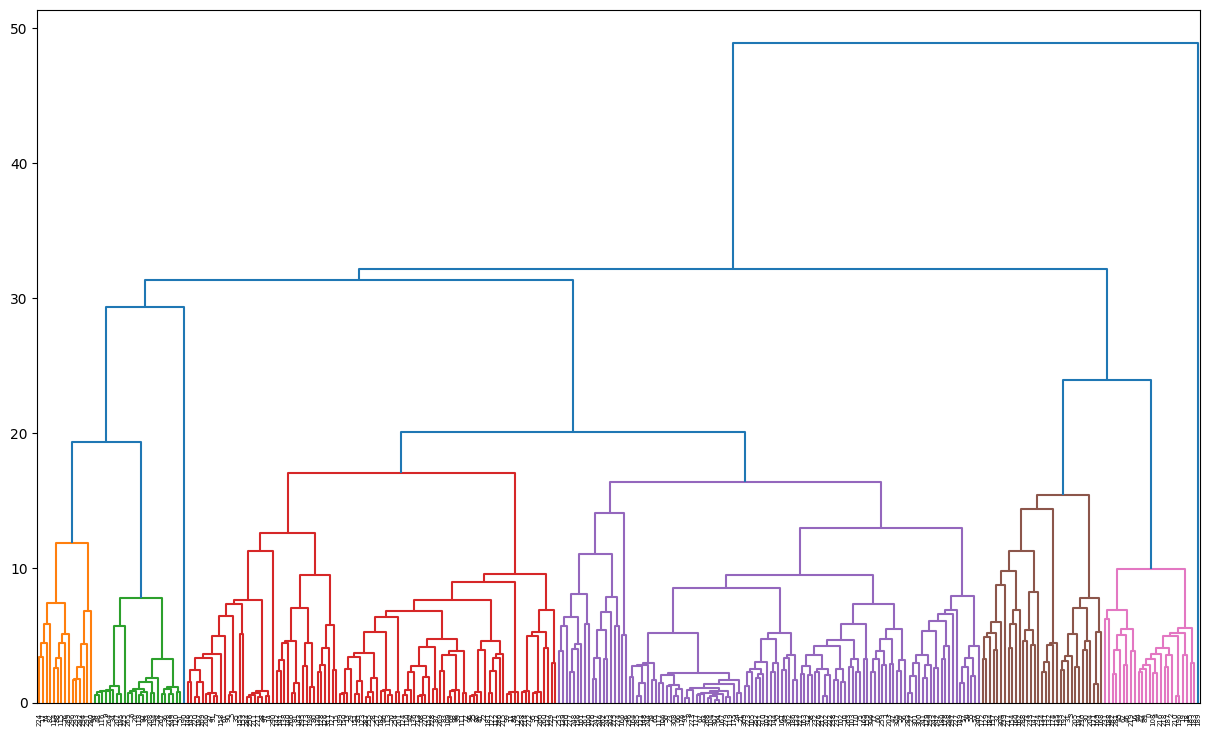

In [32]:
from new_value_analysis.actor_finder import plot_dendrogram

# 5.1 덴드로그램
linked = plot_dendrogram(
    df,
    vector_col='vector',
    method='ward',
    figsize=(15, 9),
    orientation='top'
)

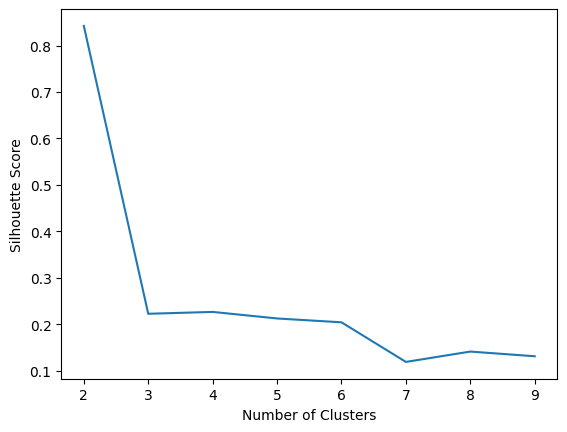

In [33]:
from new_value_analysis.actor_finder import agglomerative_silhouette_module

# 5.2 실루엣 계수 (2~10개)
agglomerative_silhouette_module(
    df,
    vector_col='vector',
    linkage='ward'
)

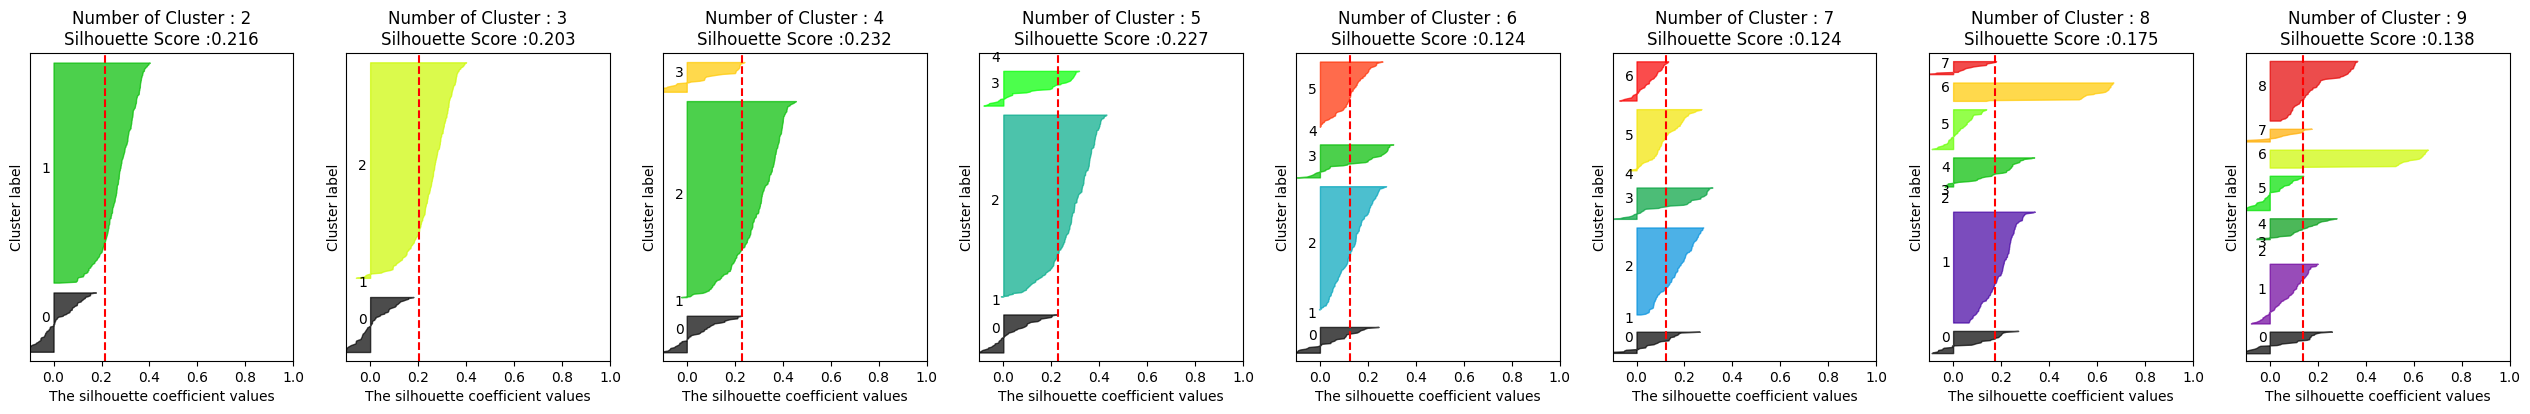

In [34]:
from new_value_analysis.actor_finder import visualize_silhouette

# 5.3 실루엣 다이어그램
visualize_silhouette(range(2, 10), list(df['vector']))

In [19]:
from sklearn.cluster import AgglomerativeClustering

# ▶ 덴드로그램 + 실루엣 결과 보고 아래 값 수정!
N_CLUSTERS = 3

cluster = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
cluster_labels = cluster.fit_predict(list(df['vector']))

df['cluster'] = cluster_labels
print('클러스터 분포:')
print(df['cluster'].value_counts().sort_index())

클러스터 분포:
cluster
0    311
1      1
2      1
Name: count, dtype: int64


### 6. TF-IDF로 클러스터 해석

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 클러스터별 문서 합치기
all_document = []
for i in sorted(df['cluster'].unique()):
    pos_tagged = df[df['cluster'] == i]['tagged_review']
    cluster_document = ' '.join([' '.join(doc) for doc in pos_tagged])
    all_document.append(cluster_document)

# TF-IDF 계산
tfidf = TfidfVectorizer()
tfidf.fit(all_document)
tfidf_vectors = tfidf.transform(all_document)

vocab = tfidf.get_feature_names_out()
tfidf_array = tfidf_vectors.toarray()
col_names = [f'군집{i}' for i in range(N_CLUSTERS)]
tfidf_df = pd.DataFrame(tfidf_array, columns=vocab).T
tfidf_df.columns = col_names

# 클러스터별 상위 키워드 출력 및 저장
for col in tfidf_df.columns:
    temp_df = tfidf_df[col].sort_values(ascending=False).head(30)
    temp_df.to_csv(f'./cluster_{col}.csv', encoding='utf-8-sig')
    print(f'\n[{col}] 상위 30개 키워드:')
    print(temp_df)


[군집0] 상위 30개 키워드:
렌탈      0.446868
가전      0.403564
구독      0.335613
가능      0.171010
혜택      0.152480
서비스     0.150576
제품      0.145652
정수기     0.142925
냉장고     0.133166
구매      0.127716
상담      0.126863
선택      0.119341
비용      0.117666
케어      0.116274
관리      0.109870
사용      0.107949
할인      0.106329
비교      0.104987
답변      0.102873
설치      0.096571
에어컨     0.090472
가전제품    0.089252
세탁기     0.085389
계약      0.084113
제휴      0.079696
부담      0.074836
사은품     0.072174
고객      0.072053
필터      0.071564
이용      0.067603
Name: 군집0, dtype: float64

[군집1] 상위 30개 키워드:
동사     0.373381
상승     0.259799
대비     0.225562
로봇     0.211464
전년     0.205422
영업     0.171185
이익     0.169171
급등     0.158886
지난해    0.158886
실적     0.157088
매출액    0.150941
테마     0.145004
기술     0.132920
배당     0.113868
기대감    0.105924
시장     0.102711
반도체    0.100628
소식     0.100096
기준     0.098683
지속     0.098683
관련     0.098532
글로벌    0.092683
증권     0.092641
순이익    0.084739
확대     0.084586
언론     0.082572
분기     0.0

In [21]:
# 최종 저장
df.to_pickle('./cluster_review.pkl')
print('✅ cluster_review.pkl 저장 완료')

✅ cluster_review.pkl 저장 완료
